In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [2]:
tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

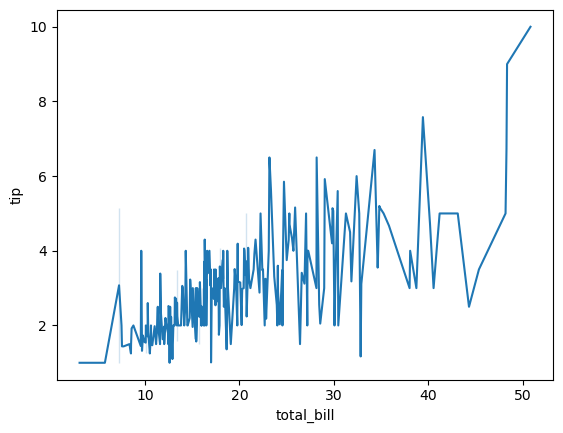

In [3]:
# basic plot

sns.lineplot(data=tips,         # choose dataset
             x = 'total_bill',  # define x variable
             y = 'tip')         # define y variable

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

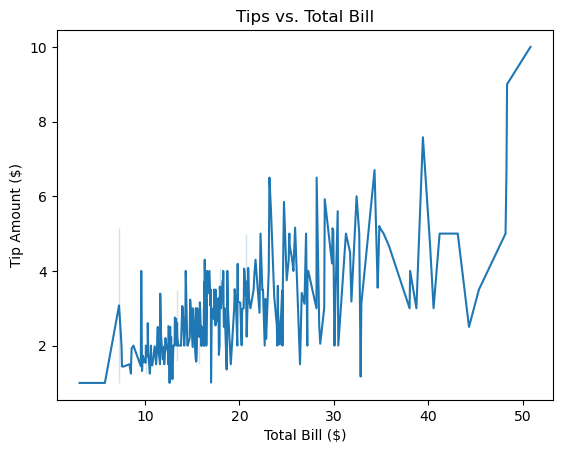

In [4]:
# add label using the set function

tipgraph = sns.lineplot(data=tips,         # choose dataset
             x = 'total_bill',  # define x variable
             y = 'tip')         # define y variable

tipgraph.set(title = 'Tips vs. Total Bill',
             xlabel = 'Total Bill ($)',
             ylabel = 'Tip Amount ($)')

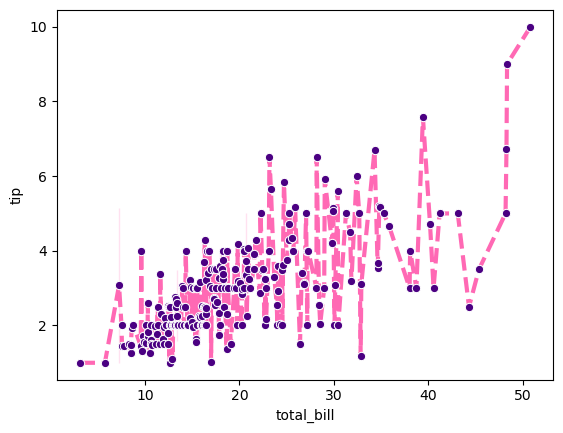

In [5]:
# modify aesthetic elements

tipgraph = sns.lineplot(data=tips,         # choose dataset
             x = 'total_bill',  # define x variable
             y = 'tip',         # define y variable
             color = 'hotpink',
             linestyle = '--',
             linewidth = 3,
             marker = 'o',
             markerfacecolor = 'indigo')         

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

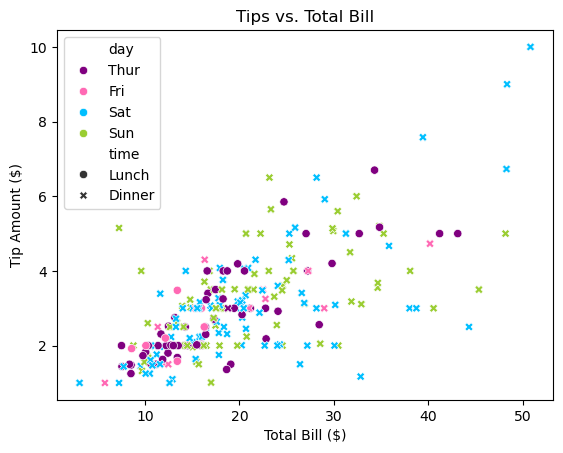

In [7]:
# we can add multiple variables

tipgraph = sns.scatterplot( data=tips,
                           x = 'total_bill',
                           y='tip',
                           style = 'time',
                           hue = 'day',
                           palette = ['purple', 'hotpink', 'deepskyblue', 'yellowgreen'])

tipgraph.set(title = 'Tips vs. Total Bill',
             xlabel = 'Total Bill ($)',
             ylabel = 'Tip Amount ($)')


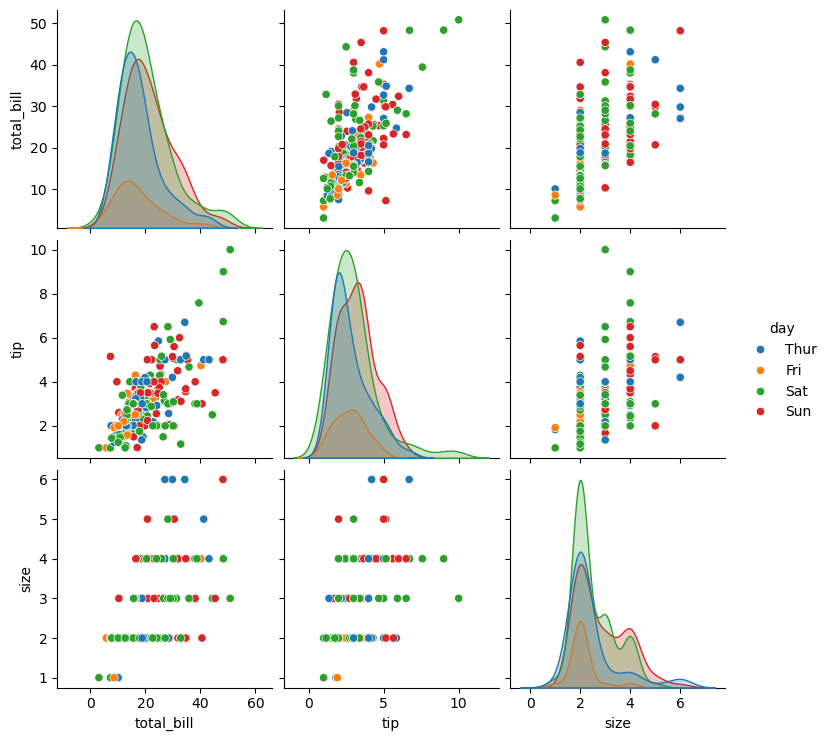

In [12]:
sns.pairplot(data=tips, hue='day')

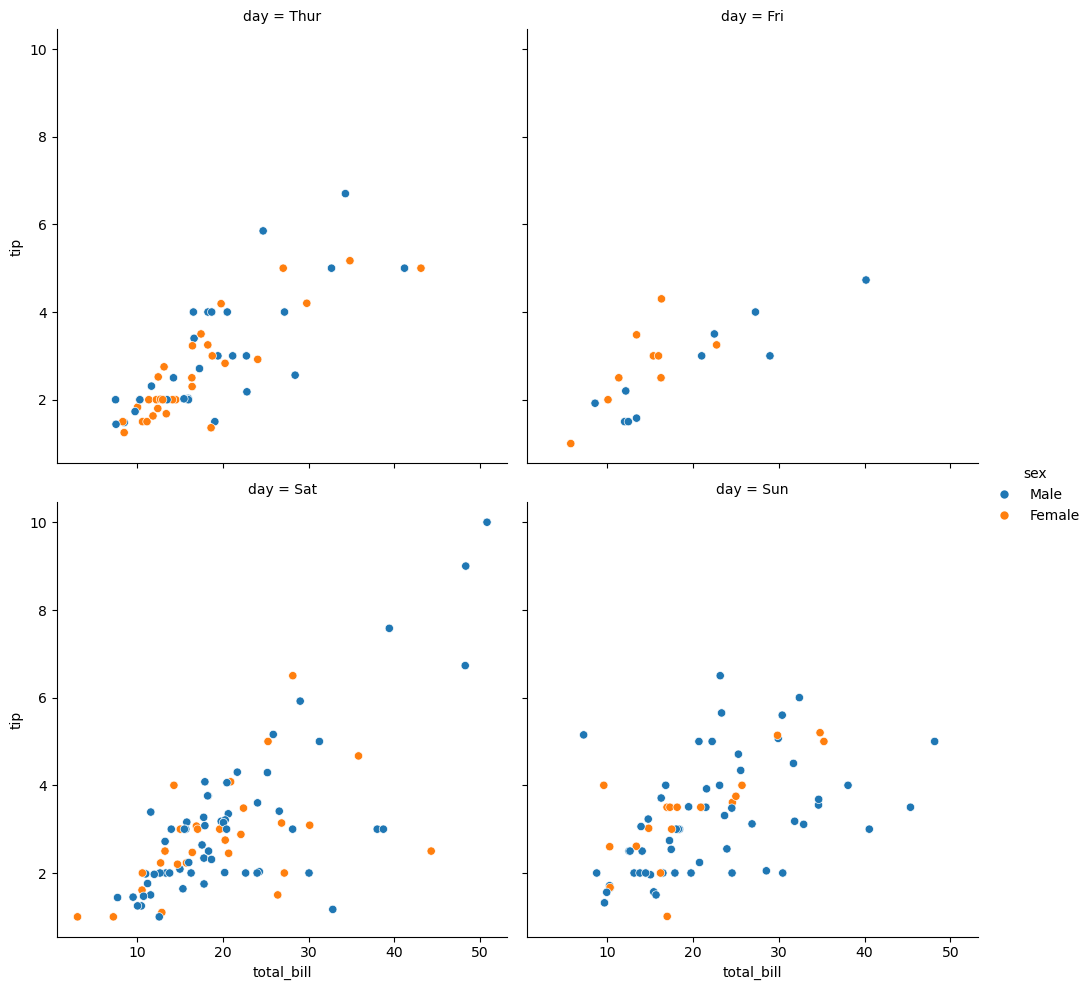

In [9]:
daysplot = sns.relplot(data = tips,
                      x = 'total_bill',
                      y = 'tip',
                      hue = 'sex',
                      col = 'day',
                      kind = 'scatter',
                      col_wrap = 2)

In [18]:
## plotly


# import packages
import plotly.graph_objects as go # go = graph objects

# load all other libraries as well
from wordcloud import WordCloud
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

In [19]:
# make some sample data

x1 = np.array(['Luffy', 'Zoro', 'Nami', 'Usopp', 'Sanji'])
y1 = np.array([110, 180, 240, 99, 220])

In [20]:
# make figure
graph = go.Figure()

# choose plot type and data
graph.add_trace(go.Bar(x=x1, y=y1))

# update our layout to include titles
graph.update_layout(
    title = 'Pirate Scores',
    xaxis_title = 'Pirates',
    yaxis_title = 'Score'
)

# we have to show our plot
graph.show()

In [21]:
# we can save our graph as html and embed them in webpages!

graph.write_html(r'C:\Users\nohag\OneDrive\Desktop\UofT\12. Winter 2025\DSI\visualization\02_activities\assignments\participation\pirategraph.html')

In [23]:
# customizing plotly graphs

graph = go.Figure()

graph.add_trace(
    go.Scatter(
        x=x1,
        y=y1,
        mode = 'markers',   # points for a scatter plot
        marker = dict(
            size = 15,                              # point size
            color = 'hotpink',                      # point color
            opacity = 1,                            # point transparency/alpha
            line = dict(width=5, color='purple')    # point outline
        )
    )
)

graph.update_layout(
    title = 'Interactive Pirate Plot', 
    xaxis_title = 'Pirates',
    yaxis_title = 'Scores',
    width = 500,
    height = 500
)

#graph.show()

In [24]:
### Making WordClouds

# load sample dataset of movie quotes

df = pd.read_csv('https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv', on_bad_lines='skip')
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(-0.5, 399.5, 199.5, -0.5)

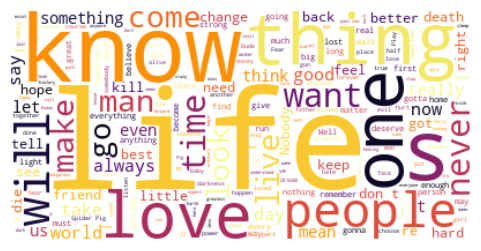

In [26]:
# make a simple wordcloud

# join all our text from each row from our quote column into a string
text = ' '.join(each for each in df.quote)

# generate our wordcloud image
wordcloud = WordCloud(background_color='white', colormap='inferno').generate(text)

# use matplotlib syntax to put our image in a figure
fig, ax = plt.subplots(figsize=(7,3))
ax.imshow(wordcloud,                    # also used 'imshow' when we added pics to our matplotlib axes
          interpolation='bilinear')     # this helps smooth our image
ax.axis('off')
#plt.show()

In [27]:
## Making Venn Diagrams

# First define our sets
A = set(['apple', 'banana', 'watermelon'])
B = set(['pumpkin', 'blueberry', 'apple', 'key lime'])

c:\Users\nohag\miniconda3\envs\dsi_participant\lib\site-packages\matplotlib_venn\_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



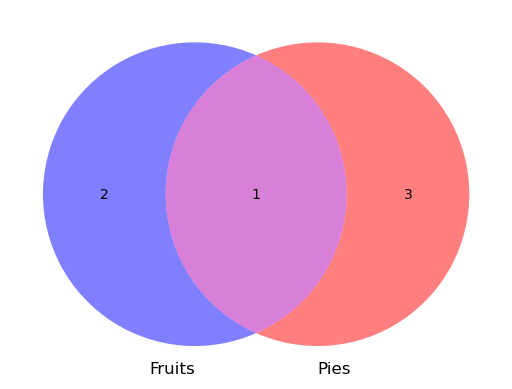

In [ ]:
# assign our sets to each circle and modify the appearance

diagram = venn2_unweighted(
    [A,B],
    set_labels= ('Fruits', 'Pies'),
    set_colors= ('blue', 'red'),
    alpha=0.5
)
## only shows counts of how many items are in each section

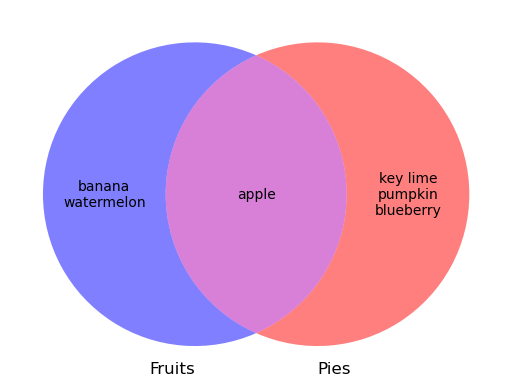

In [34]:
# Modifying the venn diagram to include the contents of the sets

diagram = venn2_unweighted(
    [A,B],                          # the sets we have
    set_labels= ('Fruits', 'Pies'), # labels for each circle
    set_colors= ('blue', 'red'),    # colors of the circles
    alpha=0.5                       # opacity of the circles
)

# numbers in the brackets are from the documentation of matplotlib_venn
diagram.get_label_by_id('10').set_text('\n'.join(A - B)) 
diagram.get_label_by_id('11').set_text('\n'.join(A & B))
diagram.get_label_by_id('01').set_text('\n'.join(B - A))
